Title: Mean_and_anomaly_calculations_VRES.ipynb

Purpose: Calculate a model mean and the wind anomaly data

Author: Onno Nennecke on 02.06.2025 Modified: 13.06.2026

Input data: 

- Wind Data from ERA5 and CMIP
    - These files lie here: /climca/people/onennecke/not_debiased_data/
- Used Runs File: CMIP6_runs.csv
    - These files lie here: /home/onennecke/CMIP_models/

Output data:

- Wind winter means Data: wind_mean_combined.nc
    - This file lies here: /climca/people/onennecke/model_output/var_means/Wind_not_bc/
- Wind Anomaly Data
    - This file lies here: /climca/people/onennecke/model_output/wind_anomaly/not_bc/
- Wind composite data
    - This file lies here: //climca/people/onennecke/model_output/composites

### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import glob
import time
# import cftime

### Load VRES Dates

In [2]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'
ts_datasets = xr.open_dataset(path)
ts_datasets.load()

ts_datasets_week = ts_datasets.sel(ESM_run=ts_datasets.ESM_run[ts_datasets.period == 'week'])
RL_week = ts_datasets_week['Residual_load']
thresh_perc = 0.95
threshold_week = np.quantile(RL_week.values.flatten(), thresh_perc)
threshold_week

# Create a boolean mask for values above the threshold
mask_week = RL_week > threshold_week
mask_week

<xarray.DataArray 'Residual_load' (ESM_run: 193, time: 3650)> Size: 704kB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False,  True, ..., False, False,  True],
       [False, False, False, ..., False,  True,  True]])
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r7i1p1f2' 'r8i1p1f2'
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r8i1...
    country   float64 8B 9.0
    period    (ESM_run) <U4 3kB 'week' 'week' 'week' ... 'week' 'week' 'week'
    doy       (time) int64 29kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365

## Choose variable

In [3]:
# 
# ['sfcWind', 'tas', 'rsds', 'tasmax']
var = 'rsds'

### Read data

In [4]:
# Read the dataframe from the csv file
used_runs_CMIP = pd.read_csv('/home/onennecke/CMIP_models/CMIP6_runs_future.csv')

used_runs_CESM = pd.read_csv('/home/onennecke/CMIP_models/CESM2_LE_runs.csv')

used_runs = pd.concat([used_runs_CMIP, used_runs_CESM], ignore_index=True)

# Add one row with ERA5 using pd.concat
era5_row = pd.DataFrame([{
    'ESM': 'ERA5',
    'Institution': 'ECMWF',
    'run': 'hist'
}])
used_runs = pd.concat([used_runs, era5_row], ignore_index=True)


# Change the ref column to 1 for the first instance of each model
used_runs['Ref'] = used_runs.groupby(['ESM', 'Institution']).cumcount().apply(lambda x: 1 if x == 0 else 0)

used_runs['names'] = used_runs['ESM'] + '_' + used_runs['run']

ESMs = used_runs['ESM'].unique()

used_runs

,ESM,Institution,run,Ref,names
0,ACCESS-CM2,CSIRO-ARCCSS,r4i1p1f1,1,ACCESS-CM2_r4i1p1f1
1,ACCESS-CM2,CSIRO-ARCCSS,r5i1p1f1,0,ACCESS-CM2_r5i1p1f1
2,ACCESS-CM2,CSIRO-ARCCSS,r1i1p1f1,0,ACCESS-CM2_r1i1p1f1
3,BCC-CSM2-MR,BCC,r1i1p1f1,1,BCC-CSM2-MR_r1i1p1f1
4,CESM2,NCAR,r4i1p1f1,1,CESM2_r4i1p1f1
...,...,...,...,...,...
188,CESM2,NCAR,LE2-1301_017,0,CESM2_LE2-1301_017
189,CESM2,NCAR,LE2-1301_018,0,CESM2_LE2-1301_018
190,CESM2,NCAR,LE2-1301_019,0,CESM2_LE2-1301_019
191,CESM2,NCAR,LE2-1301_020,0,CESM2_LE2-1301_020


In [5]:
base_path = '/climca/people/onennecke/not_debiased_data/'

# Show all files in the base path
files = os.listdir(base_path)
Var_files = [fn for fn in files if f'_{var}.' in os.path.basename(fn)]
print(len(Var_files))

# Filter Var_files to only include those that are in the used_runs dataframe
Var_files = [fn for fn in Var_files if any(name in fn for name in used_runs['names'])] 
print(len(Var_files))

# Combine the base path with the file names
Var_files = [os.path.join(base_path, fn) for fn in Var_files]

Var_ds = xr.open_dataset(Var_files[0])  # Open the first file to check the structure
Var_ds.load()

# Open the files using xarray
# Var_ds = xr.open_mfdataset(Var_files, combine='by_coords')

201
193


<xarray.Dataset> Size: 1MB
Dimensions:   (time: 3650, lat: 9, lon: 10)
Coordinates:
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       <U8 32B 'CESM2_LE'
    run       <U12 48B 'LE2-1281_010'
    ESM_run   <U21 84B 'CESM2_LE_LE2-1281_010'
Data variables:
    rsds      (time, lat, lon) float32 1MB 0.0 0.0 0.0 0.0 ... 28.57 23.48 16.11
Attributes:
    regrid_method:  bilinear

In [6]:
# # Calculate the mean over the ESM dimension and save it to a new file
# for esm in ESMs:
#     ds_list = []
#     esm_files = [fn for fn in Var_files if esm in os.path.basename(fn)]
#     # print(f'Processing {esm} with {len(esm_files)} files...')
#     if esm != 'CESM2':
#         continue  # Skip non-CESM2 models for now
#     for fn in esm_files:
#         # print(f'Opening file: {fn}')
#         ds = xr.open_dataset(fn)
#         esm_run = ds.ESM_run.values
#         print(esm_run)
#         if esm == 'CESM2' and str(esm_run).split('_').__len__() >= 3:
#             esm_run = str(esm_run).split('_')[0] + '_' + str(esm_run).split('_')[2] + '_' + str(esm_run).split('_')[3]
#             print('becomes', esm_run)
#         # Select only the masked days
#         # ds = ds.where(mask_week.sel(ESM_run=esm_run), drop=True)
#         # if esm == 'CESM2':
#         #     break
#     # break

In [6]:
# Calculate the mean over the ESM dimension and save it to a new file
for esm in ESMs:
    ds_list = []
    esm_files = [fn for fn in Var_files if esm in os.path.basename(fn)]
    print(f'Processing {esm} with {len(esm_files)} files...')
    for fn in esm_files:
        print(f'Opening file: {fn}')
        ds = xr.open_dataset(fn)
        esm_run = ds.ESM_run.values
        if esm == 'CESM2' and str(esm_run).split('_').__len__() >= 3:
            esm_run = str(esm_run).split('_')[0] + '_' + str(esm_run).split('_')[2] + '_' + str(esm_run).split('_')[3]
        if esm == 'ERA5':
            esm_run = 'ERA5_hist_week'
        # Select only the masked days
        ds = ds.where(mask_week.sel(ESM_run=esm_run), drop=True)
        print(esm_run, ' has so many values: ', mask_week.sel(ESM_run=esm_run).sum())
        # Select only 6 winter months (October to March)
        ds = ds.sel(time=ds['time.month'].isin([10, 11, 12, 1, 2, 3]))
        
        # Calculate the mean over the time dimension
        mean_ts_ds = ds.mean(dim='time', keep_attrs=True)
        
        ts_output = mean_ts_ds.expand_dims(ESM_run=[esm_run]).assign_coords(ESM_run=[esm_run])
        ds_list.append(ts_output)

    Var_esm_ds = xr.concat(ds_list, dim="ESM_run")

    Var_esm_mean = Var_esm_ds.mean(dim='ESM_run')

    # If there is a run coordinate, remove it
    if 'run' in Var_esm_mean.coords:
        Var_esm_mean = Var_esm_mean.reset_coords('run', drop=True)

    Var_esm_mean = Var_esm_mean.expand_dims(ESM=[esm])
    
    # Save the mean dataset to a new file
    # output_file = (f'/climca/people/onennecke/model_output/var_means/Wind_not_bc/Wind_mean_{esm}.nc')
    output_file = (f'/climca/people/onennecke/model_output/var_means/current_climate/VRES_days/{var}_mean_{esm}.nc')
    Var_esm_mean.to_netcdf(output_file)
    print(f'Saved mean dataset for {esm} to {output_file}')


Processing ACCESS-CM2 with 3 files...
Opening file: /climca/people/onennecke/not_debiased_data/ACCESS-CM2_r1i1p1f1_tas.nc
ACCESS-CM2_r1i1p1f1  has so many values:  <xarray.DataArray 'Residual_load' ()> Size: 8B
array(217)
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    ESM       <U13 52B 'ACCESS-CM2'
    run       <U12 48B 'r1i1p1f1'
    ESM_run   <U23 92B 'ACCESS-CM2_r1i1p1f1'
    country   float64 8B 9.0
    period    <U4 16B 'week'
Opening file: /climca/people/onennecke/not_debiased_data/ACCESS-CM2_r5i1p1f1_tas.nc
ACCESS-CM2_r5i1p1f1  has so many values:  <xarray.DataArray 'Residual_load' ()> Size: 8B
array(180)
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    ESM       <U13 52B 'ACCESS-CM2'
    run       <U12 48B 'r5i1p1f1'
    ESM_run   <U23 92B 'ACCESS-CM2_r5i1p1f1'
    country   float64 8B 9.0
    period    <U4 16B 'week'
Opening file: /climca/people/onennecke/not_debiased_data/ACCESS-CM2_r4i1p1f1_tas.nc
ACCESS-CM2_r4i1p1f1 

---

In [6]:
path = f'/climca/people/onennecke/model_output/var_means/current_climate/VRES_days/'
files = sorted(glob.glob(os.path.join(path, f'{var}*.nc')))

files
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM')

ts_datasets.load()

<xarray.Dataset> Size: 5kB
Dimensions:   (ESM: 11, lat: 9, lon: 10)
Coordinates:
  * ESM       (ESM) <U13 572B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'UKESM1-0-LL'
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
    country   float64 8B 9.0
    period    <U4 16B 'week'
Data variables:
    rsds      (ESM, lat, lon) float32 4kB 57.78 60.13 62.33 ... 29.3 28.72 27.41

---

In [8]:
# Add one combinded dataset for all ESMs as a new ESM variable called 'combined'
ts_combined = ts_datasets.mean(dim='ESM', keep_attrs=True)
ts_combined = ts_combined.assign_coords(ESM='Combined')
# Combine the datasets
ts_datasets = xr.concat([ts_datasets, ts_combined], dim='ESM')
ts_datasets.ESM

<xarray.DataArray 'ESM' (ESM: 12)> Size: 624B
array(['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'ERA5', 'GFDL-ESM4',
       'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1', 'UKESM1-0-LL',
       'Combined'], dtype='<U13')
Coordinates:
  * ESM       (ESM) <U13 624B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'Combined'
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    country   float64 8B 9.0
    period    <U4 16B 'week'

In [9]:
encoding = {}

all_vars = {**ts_datasets.data_vars, **ts_datasets.coords}

for var_, da in all_vars.items():
    if da.dtype.kind in {"U", "S"}:
        values = da.values.astype(str)
        if values.ndim == 0:
            maxlen = len(str(values))
        else:
            maxlen = max(map(len, values.flatten()))
        encoding[var_] = {"dtype": f"U{maxlen}"}
encoding

{'ESM': {'dtype': 'U13'},
 'gridtype': {'dtype': 'U6'},
 'period': {'dtype': 'U4'}}

In [10]:
# Save the combined dataset
ts_datasets.to_netcdf(f'/climca/people/onennecke/model_output/var_means/current_climate/VRES_days_combined/{var}_mean_combined.nc', encoding=encoding)

In [7]:
# Open the combined dataset
ts_combined = xr.open_dataset(f'/climca/people/onennecke/model_output/var_means/current_climate/VRES_days_combined/{var}_mean_combined.nc')
ts_combined.load()

<xarray.Dataset> Size: 5kB
Dimensions:   (ESM: 12, lat: 9, lon: 10)
Coordinates:
  * ESM       (ESM) <U13 624B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'Combined'
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
    country   float64 8B 9.0
    period    <U4 16B 'week'
Data variables:
    rsds      (ESM, lat, lon) float32 4kB 57.78 60.13 62.33 ... 27.27 26.66

#### Plot

In [8]:
lon_edges = ts_combined.lon.values
lat_edges = ts_combined.lat.values

def setup_gridlines(ax, deg = 2, alpha = 0.4, ll = True, bl = True, label_size = 10):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    if not ll:
        gl.left_labels = False
    if not bl:
        gl.bottom_labels = False
    gl.xlabel_style = {'size': label_size}
    gl.ylabel_style = {'size': label_size}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)
    xticks = np.arange(lon_edges.min(), lon_edges.max() + deg, deg)
    yticks = np.arange(lat_edges.min() + 1, lat_edges.max() + deg, deg)
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    # only draw ticks on the bottom & left
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(labelbottom=False, labelleft=False, labelsize=10)

/tmp/ipykernel_481154/4285283086.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.97])  # Leave space for colorbar and title


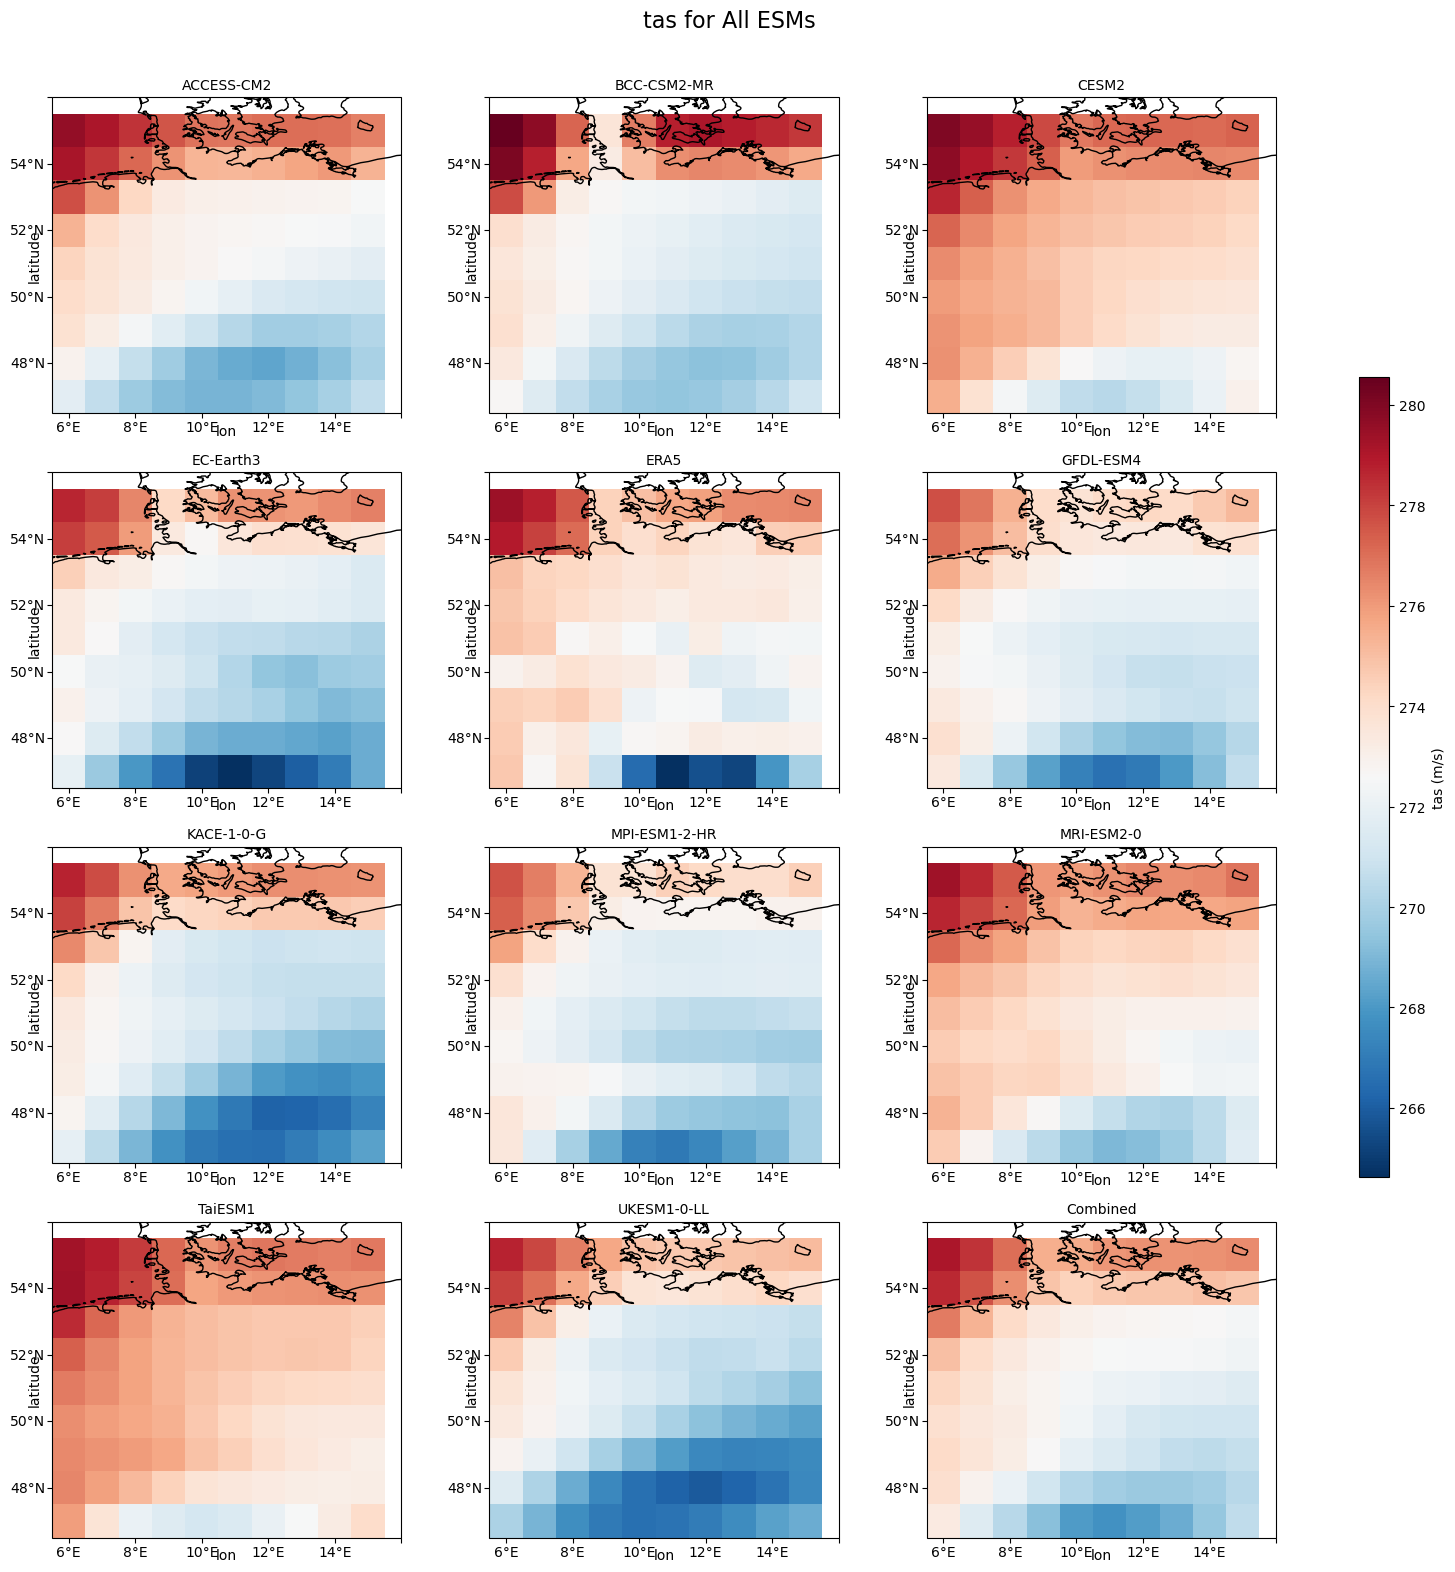

In [13]:
# Define vmin and vmax once
vmin = ts_combined[var].where(ts_combined[var] > 0).min()
vmax = ts_combined[var].max()

# Get ESM list and determine subplot layout
esm_list = ts_combined.ESM.values
n = len(esm_list)

# Choose rows/cols for subplot grid (auto-fit)
ncols = 3
nrows = (n + ncols - 1) // ncols  # ceil division

# Create a big figure
fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         subplot_kw={'projection': ccrs.PlateCarree()})

# Flatten axes for easier indexing (handles both 1D/2D cases)
axes = axes.flatten()

for i, ESM in enumerate(esm_list):
    # print('ESM:', ESM)
    ds = ts_combined.sel(ESM=ESM)
    
    # Shift longitudes
    new_lon = ((ds[var].lon + 180) % 360) - 180
    da2 = ds[var].assign_coords(lon=new_lon)

    # Plot on respective axis
    ax = axes[i]
    p = da2.plot(ax=ax, transform=ccrs.PlateCarree(),
                 cmap='RdBu_r', add_colorbar=False,
                 vmin=vmin, vmax=vmax)

    ax.coastlines()
    setup_gridlines(ax, deg=2, alpha=0)
    ax.set_title(f'{ESM}', fontsize=10)

# Remove unused axes if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add one shared colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])  # [left, bottom, width, height]
plt.colorbar(p, cax=cbar_ax, label=f'{var} (m/s)')

fig.suptitle(f'{var} for All ESMs', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.97])  # Leave space for colorbar and title
plt.show()

## Calculate Anomaly

In [10]:
for Var_fl in Var_files:
    run_time = time.time()
    nc = xr.open_mfdataset(Var_fl)
    ESM = nc.ESM.values
    if ESM == 'CESM2_LE':
        ESM = 'CESM2'
    run = nc.run.values
    esm_run = f'{ESM}_{run}'
    if esm_run == 'ERA5_hist':
        esm_run = 'ERA5_hist_week'
    print(f'Processing {ESM}, {run}')
    # if ESM == 'EC-Earth3' and run == 'r131i1p1f1':
    #     print('Skipping EC-Earth3, r131i1p1f1')
    #     continue
    nc = nc.where(mask_week.sel(ESM_run=esm_run), drop=True)

    # Filter to only winter months (October to March)
    nc = nc.sel(time=nc.time.dt.month.isin([10, 11, 12, 1, 2, 3]))
    Var_anomaly = nc.copy()
    # Calculate anomaly
    Var_anomaly[var] = nc[var] - ts_combined.sel(ESM = ESM)[var]

    ts_output = Var_anomaly.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
    ts_output.load()
    # ts_output.to_netcdf(f'/climca/people/onennecke/model_output/var_anomalies_VRES/{ESM}_{run}_{var}_anomaly.nc')
    ts_output.to_netcdf(f'/climca/people/onennecke/model_output/var_anomalies_VRES_against_VRES/{ESM}_{run}_{var}_anomaly.nc')
    # break


Processing CESM2, LE2-1281_010
Processing CESM2, LE2-1131_007
Processing CESM2, LE2-1111_006
Processing CESM2, LE2-1001_001
Processing CESM2, LE2-1101_006
Processing CESM2, LE2-1151_008
Processing EC-Earth3, r113i1p1f1
Processing EC-Earth3, r124i1p1f1
Processing CESM2, LE2-1191_010
Processing CESM2, LE2-1251_014
Processing EC-Earth3, r114i1p1f1
Processing CESM2, LE2-1231_013
Processing UKESM1-0-LL, r15i1p1f2
Processing CESM2, LE2-1301_014
Processing EC-Earth3, r127i1p1f1
Processing EC-Earth3, r141i1p1f1
Processing CESM2, LE2-1281_005
Processing CESM2, LE2-1251_019
Processing EC-Earth3, r134i1p1f1
Processing CESM2, LE2-1121_007
Processing MRI-ESM2-0, r2i1p1f1
Processing CESM2, LE2-1231_005
Processing CESM2, LE2-1281_002
Processing UKESM1-0-LL, r13i1p1f2
Processing CESM2, LE2-1251_011
Processing UKESM1-0-LL, r2i1p1f2
Processing CESM2, LE2-1251_004
Processing CESM2, LE2-1281_004
Processing CESM2, LE2-1301_001
Processing CESM2, r4i1p1f1
Processing CESM2, LE2-1301_005
Processing MPI-ESM1-2-

### Load data again

In [11]:
# path = f'/climca/people/onennecke/model_output/var_anomalies_VRES/'
path = f'/climca/people/onennecke/model_output/var_anomalies_VRES_against_VRES/'

files = sorted(glob.glob(os.path.join(path, f'*{var}*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

ts_datasets

<xarray.Dataset> Size: 106MB
Dimensions:   (ESM_run: 193, time: 1523, lat: 9, lon: 10)
Coordinates:
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
  * time      (time) datetime64[ns] 12kB 2015-01-01 2015-01-02 ... 2024-12-31
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r7i1p1f2' 'r8i1p1f2'
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r8i1...
    country   float64 8B 9.0
    period    <U4 16B 'week'
    doy       (time) float64 12kB dask.array<chunksize=(73,), meta=np.ndarray>
Data variables:
    rsds      (ESM_run, time, lat, lon) float32 106MB dask.array<chunksize=(1, 73, 9, 10), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

NameError: name 'setup_gridlines' is not defined

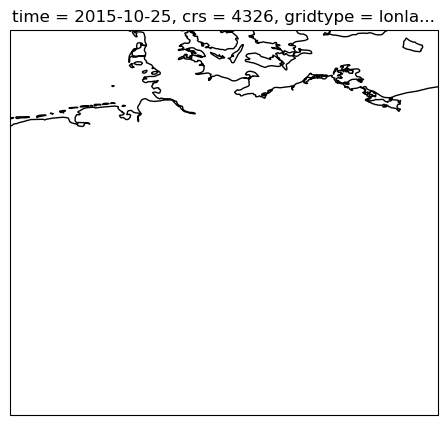

In [9]:
# Select a specific ESM run and one time step
tst = ts_datasets.sel(ESM_run='CESM2_r11i1p1f1').isel(time=89)

# Compute vmin/vmax as Python floats
# vmin_da = tst['psl'].where(tst[var] > 0).min() / 100
vmin_da = tst[var].min() / 100

vmax_da = tst[var].max() / 100

# Force evaluation and extract a scalar
vmin = float(vmin_da.compute())
vmax = float(vmax_da.compute())

# Create a figure + Cartopy axis
fig, ax = plt.subplots(
    nrows=1, ncols=1,
    figsize=(6, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Shift longitudes from [0, 360] → [–180, +180], sort, convert units, and load
new_lon = ((tst.lon + 180) % 360) - 180
da2 = tst[var].assign_coords(lon=new_lon).sortby('lon') / 100
da2 = da2.load()  # now it’s a NumPy array under the hood

# Plot with plain‐float vmin/vmax
p = da2.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    add_colorbar=False,
    vmin=vmin,
    vmax=vmax
)

ax.coastlines()
setup_gridlines(ax, deg=10, alpha=0.7)

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])
plt.colorbar(p, cax=cbar_ax, label=f'{var}')

fig.suptitle(f'{var}: ACCESS-CM2_r1i1p1f1\n {tst.time.values}', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


### Load cluster data

In [12]:
data = np.load('/home/onennecke/psl_clustering/clustering_results_nbc.npz')
labels = data['labels']
centroids_reshaped = data['centroids_reshaped']

In [13]:
path = f'/climca/people/onennecke/model_output/var_anomalies/'

files = sorted(glob.glob(os.path.join(path, f'*{var}*.nc')))
ts_datasets_filler = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

# ts_datasets_filler

In [14]:
# Read this cluster_da.to_netcdf('/home/onennecke/psl_clustering/cluster_assignments_all_days.nc')
cluster_da = xr.open_dataarray('/home/onennecke/psl_clustering/cluster_assignments_all_days.nc')
cluster_da = cluster_da.assign_coords(time=ts_datasets_filler.time)
cluster_da


<xarray.DataArray (ESM_run: 193, time: 1820)> Size: 3MB
[351260 values with dtype=int64]
Coordinates:
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r4i1p1f1' ... 'UKESM1-0-LL_r14i...
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31

In [15]:
# ---------- COMPUTE COMPOSITES ----------
clusters = np.unique(cluster_da.values)
# We'll store composites in a Dataset with a new 'cluster' dimension
composite_list = []
cluster_sizes = []

for k in clusters:
    # boolean mask for cluster k
    sel = (cluster_da == k)

    # apply mask to anomaly and average over ESM_run & time
    # .where(sel) -> retains dims (ESM_run, time, lat, lon) with NaN where False
    comp = ts_datasets.where(sel).mean(dim=['ESM_run', 'time'], skipna=True)

    # comp is a DataArray lat x lon (with ESM_run/time removed)
    composite_list.append(comp)
    cluster_sizes.append(int(sel.sum().values))  # how many samples fell into this cluster

# concat into one DataArray with cluster dim (keeps lat,lon dims)
composites = xr.concat(composite_list, dim='cluster')
composites = composites.assign_coords(cluster=('cluster', clusters))
# composites dims: cluster x lat x lon

# print("Composite shape:", composites.shape)
# print("Cluster sizes:", cluster_sizes)

In [27]:
composites.compute()

<xarray.Dataset> Size: 3kB
Dimensions:   (cluster: 4, lat: 9, lon: 10)
Coordinates:
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    country   float64 8B 9.0
    period    <U4 16B 'week'
  * cluster   (cluster) int64 32B 0 1 2 3
Data variables:
    sfcWind   (cluster, lat, lon) float64 3kB -0.3131 -0.2555 ... -0.2709

In [16]:
# Save composites to a netCDF file
# path = '/climca/people/onennecke/model_output/composites_VRES/'
path = '/climca/people/onennecke/model_output/composites_VRES_against_VRES/'

composites.to_netcdf(path + f'{var}_anomaly_composites.nc')

In [20]:
# Load composites
path = '/climca/people/onennecke/model_output/composites_VRES/'
# path = '/climca/people/onennecke/model_output/composites_VRES_against_VRES/'

composites = xr.open_dataset(path + f'{var}_anomaly_composites.nc')
composites.load()

<xarray.Dataset> Size: 2kB
Dimensions:   (cluster: 4, lat: 9, lon: 10)
Coordinates:
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * cluster   (cluster) int64 32B 0 1 2 3
Data variables:
    rsds      (cluster, lat, lon) float32 1kB 18.61 17.58 15.21 ... 2.396 2.685

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
import cartopy.crs as ccrs

In [77]:
vmax

np.float64(4.515972144952158)

/tmp/ipykernel_550023/4216231326.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


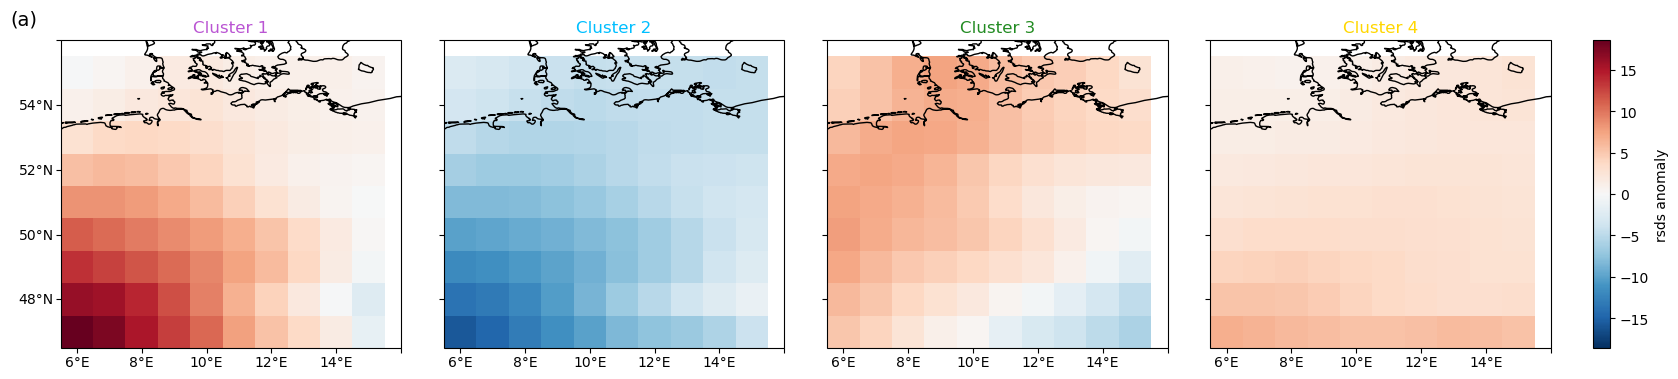

In [21]:

# Colors and desired number of subplots (mimic your example)
cluster_colors = ["mediumorchid", "deepskyblue", "forestgreen", "gold", "crimson"]
max_to_plot = 4  # plot first 5 clusters (as in example)

# Select clusters to plot (handle fewer than 5 gracefully)
clusters_all = np.array(composites['cluster'].values)
n_clusters = len(clusters_all)
n_plot = min(max_to_plot, n_clusters)
clusters_to_plot = clusters_all[:n_plot]

# Compute symmetric color limits (centered on zero)
# Use np.nanmin/np.nanmax on the values (convert to numpy; this is lazy for dask-backed arrays,
# you may want to .compute() beforehand if necessary).
vals = composites[var].values
vmin = np.nanmin(vals)
vmax = np.nanmax(vals)
# make symmetric about zero (like your example)
absmax = max(abs(vmin), abs(vmax))
vmin = -absmax
vmax = absmax

# Levels similar to your example
nlevels = 20
levels = np.linspace(vmin, vmax, nlevels)

# Coordinates for contourf
lons = composites['lon'].values
lats = composites['lat'].values

# -------------------------
# Figure and GridSpec
# -------------------------
ncols = n_plot
nrows = 1
fig = plt.figure(figsize=(5 * ncols, 4))
gs = GridSpec(nrows, ncols + 1, width_ratios=[1] * ncols + [0.05], wspace=0.15)

cmap_name = "RdBu_r"
# cmap_name = "Blues_r" # Use only white-to-blue colormap to show negative anomalies (like your example)
cmap_used = None

for i, cl in enumerate(clusters_to_plot):
    ax = fig.add_subplot(gs[0, i], projection=ccrs.PlateCarree())

    # select data for this cluster (2D lat x lon)
    da = composites[var].sel(cluster=cl)

    # ensure the array ordering matches lats x lons
    # xarray will align automatically if we pass coords to pcolormesh
    cf = ax.pcolormesh(
        lons, lats, da.values,
        vmin=vmin, vmax=vmax,
        cmap=cmap_name, transform=ccrs.PlateCarree()
    )
    cmap_used = cf.cmap

    ax.coastlines()
    # follow your pattern for gridlines (assumes setup_gridlines() exists)
    if i == 0:
        setup_gridlines(ax, deg=2, alpha=0)
    else:
        setup_gridlines(ax, deg=2, alpha=0, ll=False)

    # Title using provided cluster color list (cycle if fewer/more)
    color = cluster_colors[i % len(cluster_colors)]
    ax.set_title(f"Cluster {int(cl) + 1}", fontsize=12, color=color)

# Add (a) label like your example (position may be adjusted)
fig.text(0.1, 0.92, "(a)", fontsize=14)

# Shared vertical colorbar (use last col in GridSpec)
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])

cax = fig.add_subplot(gs[0, -1])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label(f'{var} anomaly', fontsize=10)  # replace 'units' with actual units (e.g. m/s)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
composites['lat'].values[-2:]

array([47, 48, 49, 50, 51, 52, 53, 54, 55])

/tmp/ipykernel_394695/3842017476.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


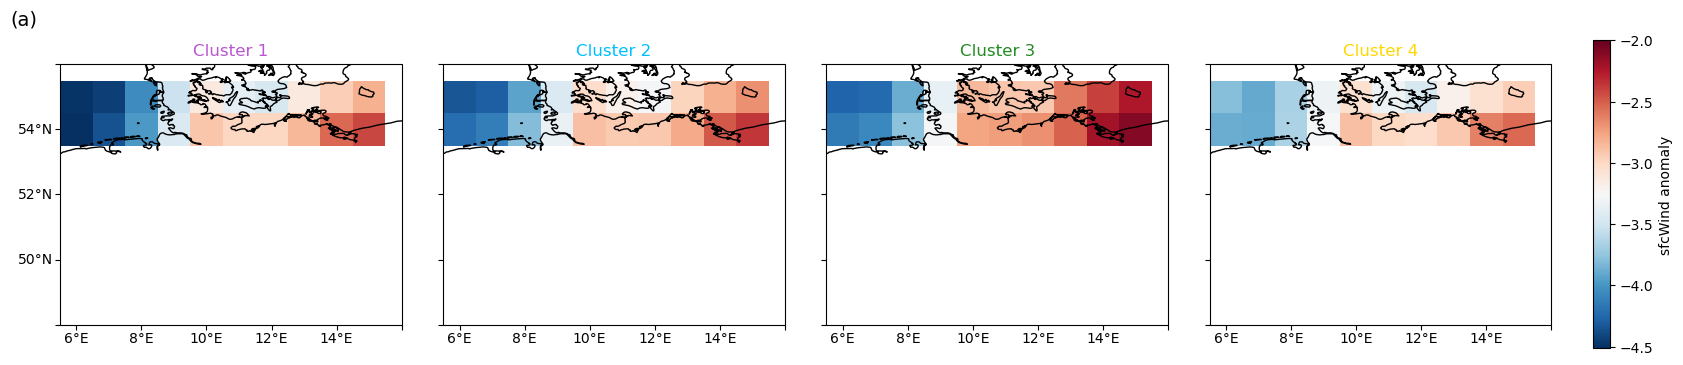

In [18]:

# Colors and desired number of subplots (mimic your example)
cluster_colors = ["mediumorchid", "deepskyblue", "forestgreen", "gold", "crimson"]
max_to_plot = 4  # plot first 5 clusters (as in example)

# Select clusters to plot (handle fewer than 5 gracefully)
clusters_all = np.array(composites['cluster'].values)
n_clusters = len(clusters_all)
n_plot = min(max_to_plot, n_clusters)
clusters_to_plot = clusters_all[:n_plot]

# Compute symmetric color limits (centered on zero)
# Use np.nanmin/np.nanmax on the values (convert to numpy; this is lazy for dask-backed arrays,
# you may want to .compute() beforehand if necessary).
vals = composites[var].values
vmin = np.nanmin(vals)
vmax = np.nanmax(vals)
# make symmetric about zero (like your example)
absmax = max(abs(vmin), abs(vmax))
vmin = -absmax
vmax = -2# 0 #absmax

# Levels similar to your example
nlevels = 20
levels = np.linspace(vmin, vmax, nlevels)

# Coordinates for contourf
lons = composites['lon'].values
lats = composites['lat'].values[-2:]

# -------------------------
# Figure and GridSpec
# -------------------------
ncols = n_plot
nrows = 1
fig = plt.figure(figsize=(5 * ncols, 4))
gs = GridSpec(nrows, ncols + 1, width_ratios=[1] * ncols + [0.05], wspace=0.15)

cmap_name = "RdBu_r"
# cmap_name = "Blues_r" # Use only white-to-blue colormap to show negative anomalies (like your example)
cmap_used = None

for i, cl in enumerate(clusters_to_plot):
    ax = fig.add_subplot(gs[0, i], projection=ccrs.PlateCarree())

    # select data for this cluster (2D lat x lon)
    da = composites[var].sel(cluster=cl)

    da = da.isel(lat=slice(-2, None))
    
    # ensure the array ordering matches lats x lons
    # xarray will align automatically if we pass coords to pcolormesh
    cf = ax.pcolormesh(
        lons, lats, da.values,
        vmin=vmin, vmax=vmax,
        cmap=cmap_name, transform=ccrs.PlateCarree()
    )
    cmap_used = cf.cmap

    ax.coastlines()
    # follow your pattern for gridlines (assumes setup_gridlines() exists)
    if i == 0:
        setup_gridlines(ax, deg=2, alpha=0)
    else:
        setup_gridlines(ax, deg=2, alpha=0, ll=False)

    # Title using provided cluster color list (cycle if fewer/more)
    color = cluster_colors[i % len(cluster_colors)]
    ax.set_title(f"Cluster {int(cl) + 1}", fontsize=12, color=color)

# Add (a) label like your example (position may be adjusted)
fig.text(0.1, 0.92, "(a)", fontsize=14)

# Shared vertical colorbar (use last col in GridSpec)
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])

cax = fig.add_subplot(gs[0, -1])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label(f'{var} anomaly', fontsize=10)  # replace 'units' with actual units (e.g. m/s)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [100]:
composites.where(composites['cluster'] == 0).dropna(dim='cluster', how='all')[var].values - composites.where(composites['cluster'] == 2).dropna(dim='cluster', how='all')[var].values

array([[[-0.3533453 , -0.30860163, -0.3282291 , -0.31635205,
         -0.27942448, -0.21251525, -0.11558901, -0.021417  ,
          0.04508223,  0.08103592],
        [-0.38274708, -0.30632095, -0.28265827, -0.30310104,
         -0.35522975, -0.36372713, -0.35534753, -0.29522088,
         -0.22445826, -0.15720448],
        [-0.42765739, -0.3717252 , -0.35134787, -0.37067848,
         -0.41307158, -0.38927969, -0.36906673, -0.33427797,
         -0.2975769 , -0.28025314],
        [-0.44628087, -0.38897938, -0.37853982, -0.40367963,
         -0.38859017, -0.3419551 , -0.3136908 , -0.30847133,
         -0.30692618, -0.30086812],
        [-0.39800784, -0.34253924, -0.33443631, -0.35089049,
         -0.32101226, -0.31371099, -0.29847475, -0.28036958,
         -0.25592386, -0.23088114],
        [-0.36065703, -0.28073827, -0.25058277, -0.2542556 ,
         -0.2461747 , -0.24901125, -0.2398593 , -0.21975081,
         -0.19860407, -0.18273517],
        [-0.39882309, -0.23538196, -0.13288339, -0.1

In [98]:
composites.where(composites['cluster'] == 1).dropna(dim='cluster', how='all')[var].values

array([[[-0.03117049, -0.03784948, -0.04215121, -0.06375837,
         -0.07894   , -0.10247718, -0.11489786, -0.12941604,
         -0.15009106, -0.16205942],
        [-0.41443528, -0.41352884, -0.39084811, -0.39655692,
         -0.42764264, -0.41117215, -0.40546421, -0.3968937 ,
         -0.38160266, -0.3792253 ],
        [-0.93071976, -0.88276764, -0.85223297, -0.89346591,
         -0.94471961, -0.89132054, -0.88115073, -0.84520996,
         -0.80220871, -0.75218646],
        [-1.36939335, -1.31410814, -1.30071367, -1.36023047,
         -1.34056814, -1.26977758, -1.23882105, -1.21736434,
         -1.19064517, -1.09627498],
        [-1.77794489, -1.7104119 , -1.73321017, -1.83445512,
         -1.75896263, -1.78564099, -1.77705208, -1.66884698,
         -1.50846688, -1.34280256],
        [-2.30460701, -2.2710386 , -2.31033213, -2.37875145,
         -2.32992141, -2.28464451, -2.18555409, -1.97811953,
         -1.73929452, -1.57259674],
        [-3.24736899, -2.99625131, -2.86198808, -2.6